In [1]:
# Analyse et optimisation du réseau de transport Bibus

#Le transport urbain joue un rôle essentiel dans la mobilité quotidienne des citoyens. La qualité d’un réseau de transport dépend de plusieurs facteurs, notamment la ponctualité des véhicules, la fréquentation des lignes et la satisfaction des voyageurs.

#L’objectif de cette étude est d’exploiter les données opérationnelles du réseau Bibus afin d’identifier les principaux facteurs à l’origine des retards, d’analyser les variations de fréquentation du réseau et d’évaluer l’impact de ces éléments sur la satisfaction des usagers.

#À travers une démarche complète de Data Analytics, ce projet mobilise des techniques de préparation des données, d’analyse exploratoire, de visualisation et d’interprétation des résultats afin de transformer les données en informations utiles à la prise de décision.

#Les conclusions de cette étude permettront de mettre en évidence des pistes d’amélioration concrètes visant à renforcer la performance opérationnelle du réseau et à améliorer l’expérience des voyageurs.


In [2]:
# chargement et exploration de mes données
import pandas as pd
dfc = pd.ExcelFile("Bibus")
dfc.sheet_names

['🚌 Trajets',
 '📍 Arrêts',
 '⚠️ Incidents',
 '⭐ Satisfaction',
 '🗺️ Lignes',
 '📋 README']

In [67]:
trajets = pd.read_excel("Bibus", header=2)
trajets.head(15)

,ID_Trajet,Date,Jour_Semaine,Mois,Trimestre,Est_Weekend,Ligne,Type_Ligne,Nom_Ligne,Arret_Depart,...,Taux_Remplissage_Pct,Distance_km,Duree_Prevue_Min,Duree_Reelle_Min,ID_Conducteur,ID_Bus,Age_Bus_Ans,Meteo,Incident,Note_Confort
0,TR00001,2024-01-24,Wednesday,January,T1,Non,T1,tram,Tram: Porte de Gouesnou - Pont de l'Iroise,Kergaradec,...,67.5,8.0,24,26,C024,BUS0021,4,Nuageux,Aucun,2.5
1,TR00002,2024-05-16,Thursday,May,T2,Non,T2,tram,Tram: Bertha von Suttner - Cavale Blanche,Landivisiau,...,33.8,5.1,15,15,C018,BUS0072,11,Nuageux,Aucun,3.7
2,TR00003,2024-01-29,Monday,January,T1,Non,4,principale,Kergaradec - Pontanézen,Saint-Marc,...,73.3,3.7,11,12,C026,BUS0059,5,Pluie légère,Aucun,4.3
3,TR00004,2024-10-14,Monday,October,T4,Non,10,interurbaine,Brest Gare - Kersaint-Plabennec,Kersaint,...,88.9,16.7,50,56,C006,BUS0007,4,Nuageux,Aucun,2.3
4,TR00005,2024-03-22,Friday,March,T1,Non,T1,tram,Tram: Porte de Gouesnou - Pont de l'Iroise,Moulin Blanc,...,88.8,11.1,33,35,C001,BUS0015,2,Vent fort,Aucun,4.1
5,TR00006,2024-05-16,Thursday,May,T2,Non,T1,tram,Tram: Porte de Gouesnou - Pont de l'Iroise,Porte de Gouesnou,...,82.5,12.7,38,45,C007,BUS0039,1,Ensoleillé,Incident voyageur,3.8
6,TR00007,2024-04-11,Thursday,April,T2,Non,3,principale,Lambézellec - Bellevue,Pen ar Creac'h,...,38.3,10.0,30,31,C002,BUS0015,2,Nuageux,Trafic dense,4.1
7,TR00008,2024-06-06,Thursday,June,T2,Non,4,principale,Kergaradec - Pontanézen,Kerangoff,...,63.3,7.1,21,22,C009,BUS0017,7,Nuageux,Incident voyageur,4.7
8,TR00009,2024-03-25,Monday,March,T1,Non,5,principale,Recouvrance - Cavale Blanche,Landivisiau,...,38.3,6.7,20,23,C043,BUS0048,4,Nuageux,Travaux,3.7
9,TR00010,2024-03-02,Saturday,March,T1,Oui,4,principale,Kergaradec - Pontanézen,Plouzané Centre,...,46.7,3.2,10,11,C004,BUS0030,12,Pluie légère,Aucun,3.6


In [11]:
trajets.columns
# ce qui montre que j'ai plus de 25 variables que je vais analyser 

Index(['ID_Trajet', 'Date', 'Jour_Semaine', 'Mois', 'Trimestre', 'Est_Weekend',
       'Ligne', 'Type_Ligne', 'Nom_Ligne', 'Arret_Depart', 'Zone_Depart',
       'Arret_Arrivee', 'Zone_Arrivee', 'Heure_Depart_Prevue',
       'Tranche_Horaire', 'Retard_Minutes', 'Statut_Ponctualite',
       'Nb_Passagers', 'Capacite_Bus', 'Taux_Remplissage_Pct', 'Distance_km',
       'Duree_Prevue_Min', 'Duree_Reelle_Min', 'ID_Conducteur', 'ID_Bus',
       'Age_Bus_Ans', 'Meteo', 'Incident', 'Note_Confort'],
      dtype='object')

In [13]:
# Je verifie la qualité des données
trajets.shape

(2000, 29)

In [14]:
trajets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Trajet             2000 non-null   object 
 1   Date                  2000 non-null   object 
 2   Jour_Semaine          2000 non-null   object 
 3   Mois                  2000 non-null   object 
 4   Trimestre             2000 non-null   object 
 5   Est_Weekend           2000 non-null   object 
 6   Ligne                 2000 non-null   object 
 7   Type_Ligne            2000 non-null   object 
 8   Nom_Ligne             2000 non-null   object 
 9   Arret_Depart          2000 non-null   object 
 10  Zone_Depart           2000 non-null   object 
 11  Arret_Arrivee         2000 non-null   object 
 12  Zone_Arrivee          2000 non-null   object 
 13  Heure_Depart_Prevue   2000 non-null   object 
 14  Tranche_Horaire       2000 non-null   object 
 15  Retard_Minutes       

In [15]:
trajets.isna().sum()

ID_Trajet               0
Date                    0
Jour_Semaine            0
Mois                    0
Trimestre               0
Est_Weekend             0
Ligne                   0
Type_Ligne              0
Nom_Ligne               0
Arret_Depart            0
Zone_Depart             0
Arret_Arrivee           0
Zone_Arrivee            0
Heure_Depart_Prevue     0
Tranche_Horaire         0
Retard_Minutes          0
Statut_Ponctualite      0
Nb_Passagers            0
Capacite_Bus            0
Taux_Remplissage_Pct    0
Distance_km             0
Duree_Prevue_Min        0
Duree_Reelle_Min        0
ID_Conducteur           0
ID_Bus                  0
Age_Bus_Ans             0
Meteo                   0
Incident                0
Note_Confort            0
dtype: int64

In [16]:
trajets.duplicated().sum()

0

In [19]:
# Mon etude est vraiment centré sur trois variable clées qui explique et optimise le reseau bibus a Brest
trajets["Retard_Minutes"].describe()
# on vois ici que en moyenne, les bus présentent un retard de 2,5 minuites 
# pour la médiane c'est la moitier des trajets présentent un retard inferieur ou egale a 1,5
# std les retards présentent une variabilité importante autour de la moyenne, ce qui suggere une ponctualité irrégulière selon les trajets

count    2000.000000
mean        2.511050
std         3.721939
min        -1.400000
25%         0.400000
50%         1.500000
75%         3.400000
max        48.900000
Name: Retard_Minutes, dtype: float64

In [18]:
trajets["Nb_Passagers"].describe()

count    2000.000000
mean       30.509500
std        16.538612
min         4.000000
25%        18.000000
50%        28.000000
75%        42.000000
max        87.000000
Name: Nb_Passagers, dtype: float64

In [20]:
trajets.columns.tolist()

['ID_Trajet',
 'Date',
 'Jour_Semaine',
 'Mois',
 'Trimestre',
 'Est_Weekend',
 'Ligne',
 'Type_Ligne',
 'Nom_Ligne',
 'Arret_Depart',
 'Zone_Depart',
 'Arret_Arrivee',
 'Zone_Arrivee',
 'Heure_Depart_Prevue',
 'Tranche_Horaire',
 'Retard_Minutes',
 'Statut_Ponctualite',
 'Nb_Passagers',
 'Capacite_Bus',
 'Taux_Remplissage_Pct',
 'Distance_km',
 'Duree_Prevue_Min',
 'Duree_Reelle_Min',
 'ID_Conducteur',
 'ID_Bus',
 'Age_Bus_Ans',
 'Meteo',
 'Incident',
 'Note_Confort']

In [21]:
trajets["Note_Confort"].describe()

count    2000.00000
mean        3.77015
std         0.90156
min         1.00000
25%         3.30000
50%         3.90000
75%         4.40000
max         5.00000
Name: Note_Confort, dtype: float64

In [23]:
trajets["Meteo"].value_counts()
# ca montre combien de jours de pluie
# combien de jours de beau temps
# quelle catégorie est la plus frequente

Meteo
Nuageux         579
Ensoleillé      517
Pluie légère    420
Pluie forte     190
Brouillard      153
Vent fort       141
Name: count, dtype: int64

In [24]:
trajets["Tranche_Horaire"].value_counts()
# ca montre la tranche horaire la plus représenté et la moins representée

Tranche_Horaire
Heure de pointe        880
Heure intermédiaire    675
Heure creuse           445
Name: count, dtype: int64

In [25]:
trajets["Est_Weekend"].value_counts()
# ca montre la proportion du trajet lieu en semaine et la proportion en weekend

Est_Weekend
Non    1393
Oui     607
Name: count, dtype: int64

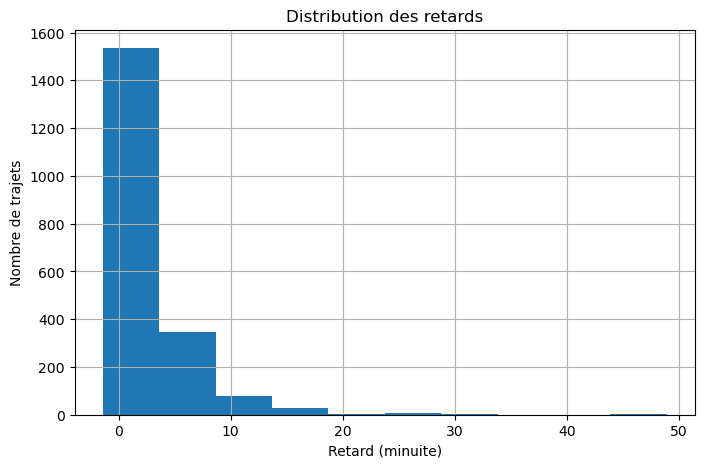

In [32]:
# Je passe a la visualisation pour mieux comprendre les données car le cerveau comprend mieux les representation que les textes
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
trajets["Retard_Minutes"].hist(bins=20)
plt.title("Distribution des retards")
plt.xlabel("Retard (minuite)")
plt.ylabel("Nombre de trajets")
plt.show()
# le bins = 20 nous dit de découpé les données en 20 intervalles ou classe 
# les retard sont concentrer au tours d'une valeur

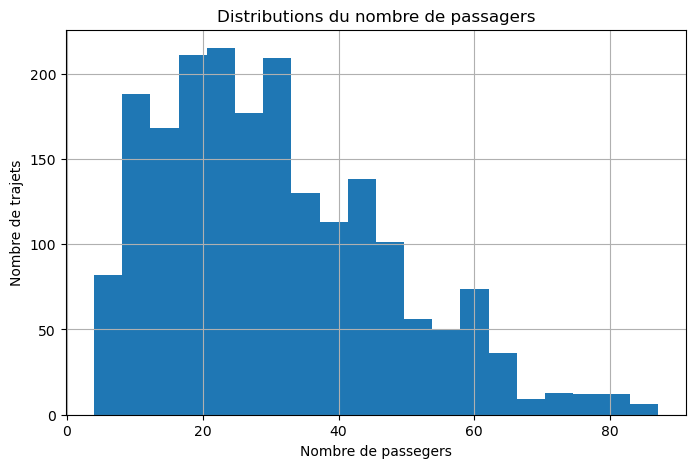

In [33]:
# Distribution du nombre de passegers
plt.figure(figsize=(8,5))
trajets["Nb_Passagers"].hist(bins=20)
plt.title("Distributions du nombre de passagers")
plt.xlabel("Nombre de passegers")
plt.ylabel("Nombre de trajets")
plt.show()

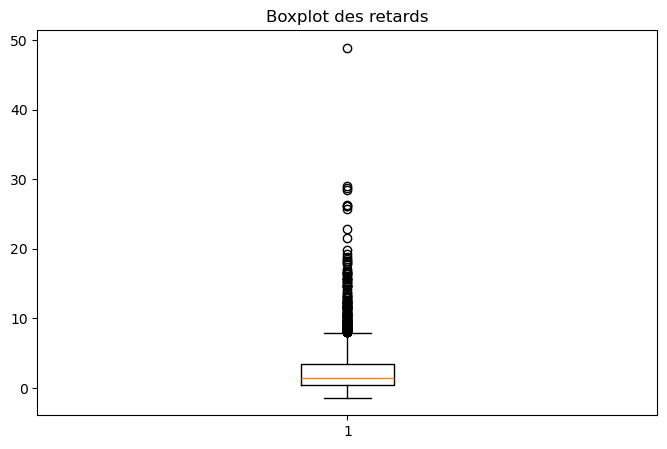

In [36]:
# Détections des valeurs extremes
#Des retards anormalement élevés
plt.figure(figsize = (8,5))
plt.boxplot(trajets["Retard_Minutes"])
plt.title("Boxplot des retards")
plt.show()

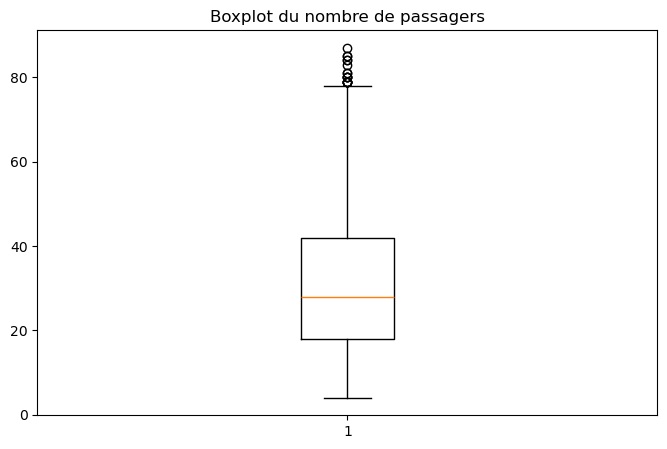

In [38]:
# Nombre de passagers
plt.figure(figsize=(8,5))
plt.boxplot(trajets["Nb_Passagers"])
plt.title("Boxplot du nombre de passagers")
plt.show()


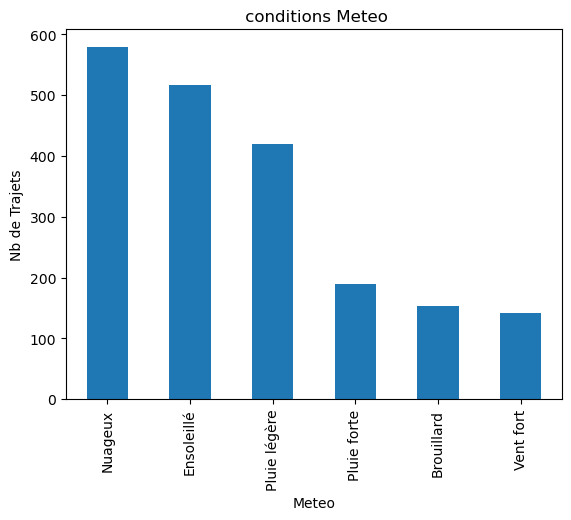

In [40]:
# Répartition de la météo
trajets["Meteo"].value_counts().plot(kind="bar")
plt.title(" conditions Meteo")
plt.xlabel("Meteo")
plt.ylabel("Nb de Trajets")
plt.show()

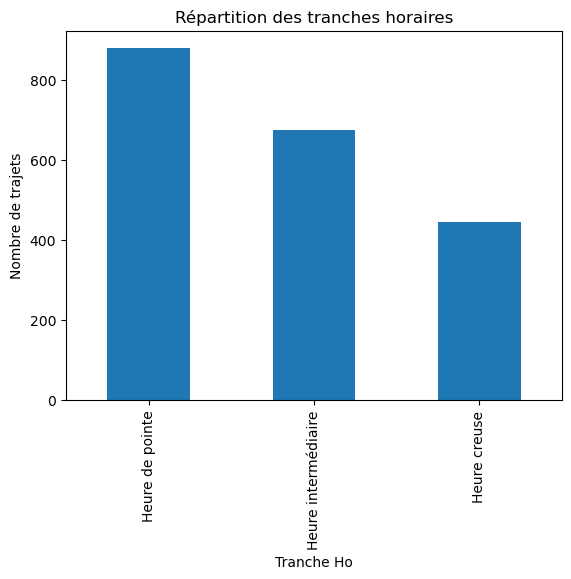

In [41]:
# répartitions des tranches horraire
trajets["Tranche_Horaire"].value_counts().plot(kind="bar")
plt.title("Répartition des tranches horaires")
plt.xlabel("Tranche Ho")
plt.ylabel("Nombre de trajets")
plt.show()


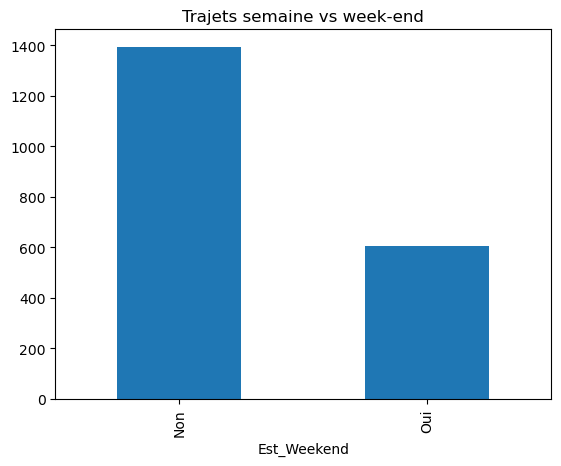

In [45]:
trajets["Est_Weekend"].value_counts().plot(kind="bar")
plt.title("Trajets semaine vs week-end")
plt.show()

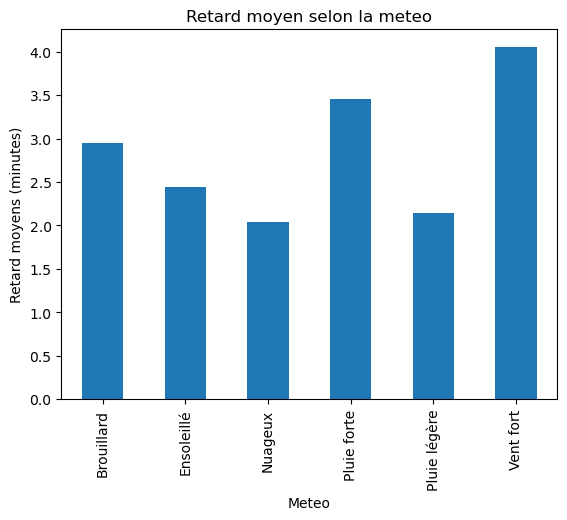

In [46]:
# retard selon la meteo
trajets.groupby("Meteo")["Retard_Minutes"].mean().plot(kind="bar")
plt.title("Retard moyen selon la meteo")
plt.ylabel("Retard moyens (minutes)")
plt.show()

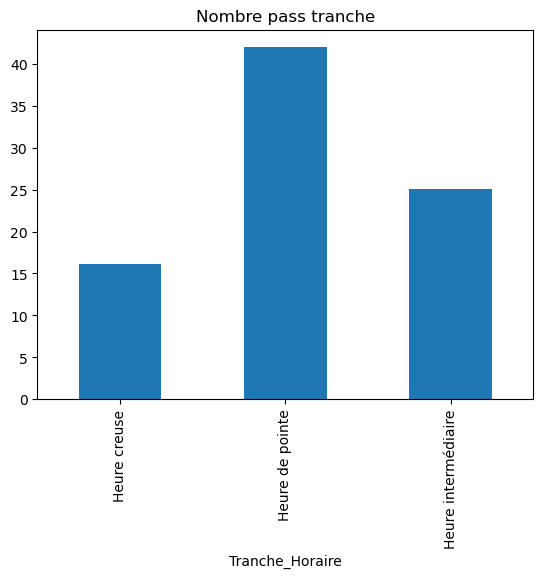

In [47]:
# freaquentation selon les tranches horaire
trajets.groupby("Tranche_Horaire")["Nb_Passagers"].mean().plot(kind="bar")
plt.title("Nombre pass tranche")
plt.show()

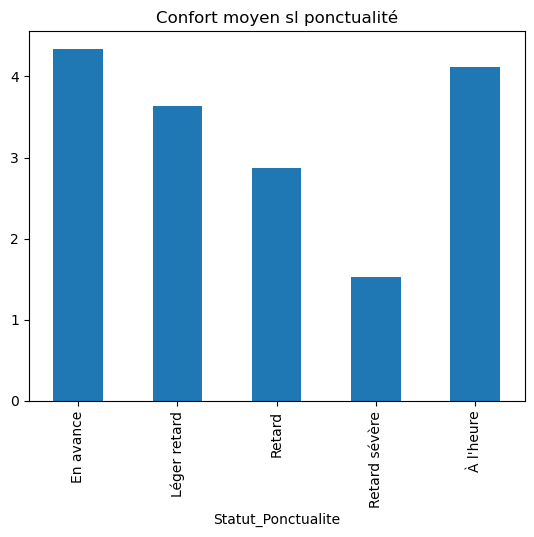

In [48]:
# confort selon le statut de ponctualité
trajets.groupby("Statut_Ponctualite")["Note_Confort"].mean().plot(kind="bar")
plt.title("Confort moyen sl ponctualité")
plt.show()

In [54]:
#import seaborn as sns
#colonnes = [ " Retard_Minutes", "Nb_Passagers", "Taux_Remplissage_Pct", "Note_Confort" ]
#sns.heatmap(
    #trajets[colonnes].corr(),
    #annot=True
#plt.title("Matrice des corrélations")
#plt.show()

In [55]:
trajets.groupby("Meteo")["Retard_Minutes"].agg(
    ["count", "mean", "median", "max"]
).sort_values(by="mean", ascending=False)

,count,mean,median,max
Meteo,,,,
Vent fort,141,4.052482,2.4,48.9
Pluie forte,190,3.450000,2.0,29.0
Brouillard,153,2.949020,1.8,21.6
Ensoleillé,517,2.437331,1.5,18.3
Pluie légère,420,2.146905,1.3,26.3
Nuageux,579,2.041796,1.3,26.2


In [56]:
# on constate que Les retards moyens sont plus élevés en cas de pluie et de brouillard. Les conditions météorologiques semblent donc avoir un impact sur la ponctualité du réseau.
# le retard moyen varie de 2,04 minute ( Nuageux) a 4,05 minutes (Vent fort)
# Les conditions météorologiques difficiles sont associées à des retards plus élevés que les conditions normales.

In [57]:
trajets.groupby("Incident")["Retard_Minutes"].agg(
    ["count", "mean", "median", "max"]
).sort_values(by="mean", ascending=False)

,count,mean,median,max
Incident,,,,
Incident voyageur,125,3.239200,2.00,29.0
Aucun,1217,2.515859,1.50,48.9
Conditions météo,147,2.472789,1.60,26.2
Panne mécanique,120,2.450000,1.50,26.2
Travaux,135,2.423704,1.40,16.5
Accident sur voie,138,2.296377,1.15,19.2
Trafic dense,118,2.150847,1.45,22.9


In [58]:
# ici on constate que Les incidents voyageurs génèrent le retard moyen le plus élevé : 3,24 minutes.
#Les trajets touchés par des incidents voyageurs semblent plus perturbés que les autres catégories

In [59]:
trajets.groupby("Tranche_Horaire")["Retard_Minutes"].agg(
    ["count", "mean", "median"]
).sort_values(by="mean", ascending=False)


,count,mean,median
Tranche_Horaire,,,
Heure de pointe,880,4.051705,2.7
Heure intermédiaire,675,1.437333,1.0
Heure creuse,445,1.093034,0.8


In [60]:
# Le retard moyen atteint 4,05 minutes en heure de pointe contre seulement 1,09 minute en heure creuse.
# Les heures de pointe constituent le principal facteur de retard du réseau.

In [61]:
trajets.groupby("Ligne")["Retard_Minutes"].agg(
    ["count", "mean", "median"]
).sort_values(by="mean", ascending=False)

,count,mean,median
Ligne,,,
10,173,3.049711,1.80
8,154,2.907792,1.90
4,182,2.882967,1.70
2,173,2.775723,1.50
5,162,2.756173,1.80
7,173,2.741618,1.40
6,141,2.675177,1.70
1,172,2.630814,1.85
12,175,2.609143,1.50


In [62]:
# La ligne 10 présente le retard moyen le plus élevé (3,05 minutes), tandis que les lignes de tramway T1 et T2 sont les plus ponctuelles.
# Les performances varient selon les lignes, ce qui suggère des contraintes opérationnelles différentes

In [63]:
trajets.groupby("Tranche_Horaire")["Nb_Passagers"].agg(
    ["count", "mean", "median", "max"]
).sort_values(by="mean", ascending=False)

,count,mean,median,max
Tranche_Horaire,,,,
Heure de pointe,880,41.978409,41.0,87
Heure intermédiaire,675,25.035556,24.0,59
Heure creuse,445,16.132584,14.0,49


In [64]:
# La fréquentation moyenne passe de 16 voyageurs en heure creuse à près de 42 voyageurs en heure de pointe.
# La demande est fortement concentrée durant les heures de pointe.

In [65]:
trajets[["Retard_Minutes", "Note_Confort"]].corr()
# les retards influencent il le confort?

,Retard_Minutes,Note_Confort
Retard_Minutes,1.000000,-0.696595
Note_Confort,-0.696595,1.000000


In [66]:
# Une forte relation négative est observée entre les retards et le confort perçu.
# Plus les retards augmentent, plus la note de confort diminue.


In [ ]:


# A base de toutes ses analyses  on arrive a la conclusion suivante:

# L’analyse des données du réseau Bibus met en évidence plusieurs facteurs influençant la qualité du service. Les retards sont principalement observés durant les heures de pointe, lorsque la fréquentation du réseau atteint son niveau maximal. Les conditions météorologiques défavorables et certains types d’incidents, notamment les incidents voyageurs, contribuent également à la dégradation de la ponctualité.

# L’étude montre également que les performances varient selon les lignes, certaines lignes de bus présentant des retards moyens plus importants que les lignes de tramway. Enfin, une forte relation négative a été observée entre les retards et le confort perçu par les voyageurs, indiquant que la ponctualité constitue un élément essentiel de la qualité de service.

# Ces résultats suggèrent que les actions d’amélioration devraient prioritairement cibler la gestion des heures de pointe, la prévention des incidents et l’optimisation des lignes les plus exposées aux retards afin d’améliorer l’expérience globale des usagers.